# **Supervised Learning**

## **JANGAN LUPA DI DOWNLOAD TERLEBIH DAHULU, ATAU DI SALIN TERLEBIH DAHULU SEBELUM MENJALANKAN PROGRAMNYA :)))**

## 1. Regression

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
%matplotlib inline

Untuk latihan pada kali ini, kita akan memakai dataset bawaan dari Google Colab yaitu dataset `USA_Housing.csv`

In [94]:
# membaca dataset ke dataframe
df = pd.read_csv('USA_Housing.csv')
df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


### Exploratory Data Analysis


In [95]:
# melihat cuplikan informasi mengenai dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   object 
dtypes: float64(6), object(1)
memory usage: 273.6+ KB


In [96]:
# statistika deskriptif mengenai dataset kita
df.describe(include='all')

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03,5000
unique,NaN,NaN,NaN,NaN,NaN,NaN,5000
top,NaN,NaN,NaN,NaN,NaN,NaN,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
freq,NaN,NaN,NaN,NaN,NaN,NaN,1
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06,NaN
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05,NaN
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04,NaN
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05,NaN
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06,NaN
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06,NaN


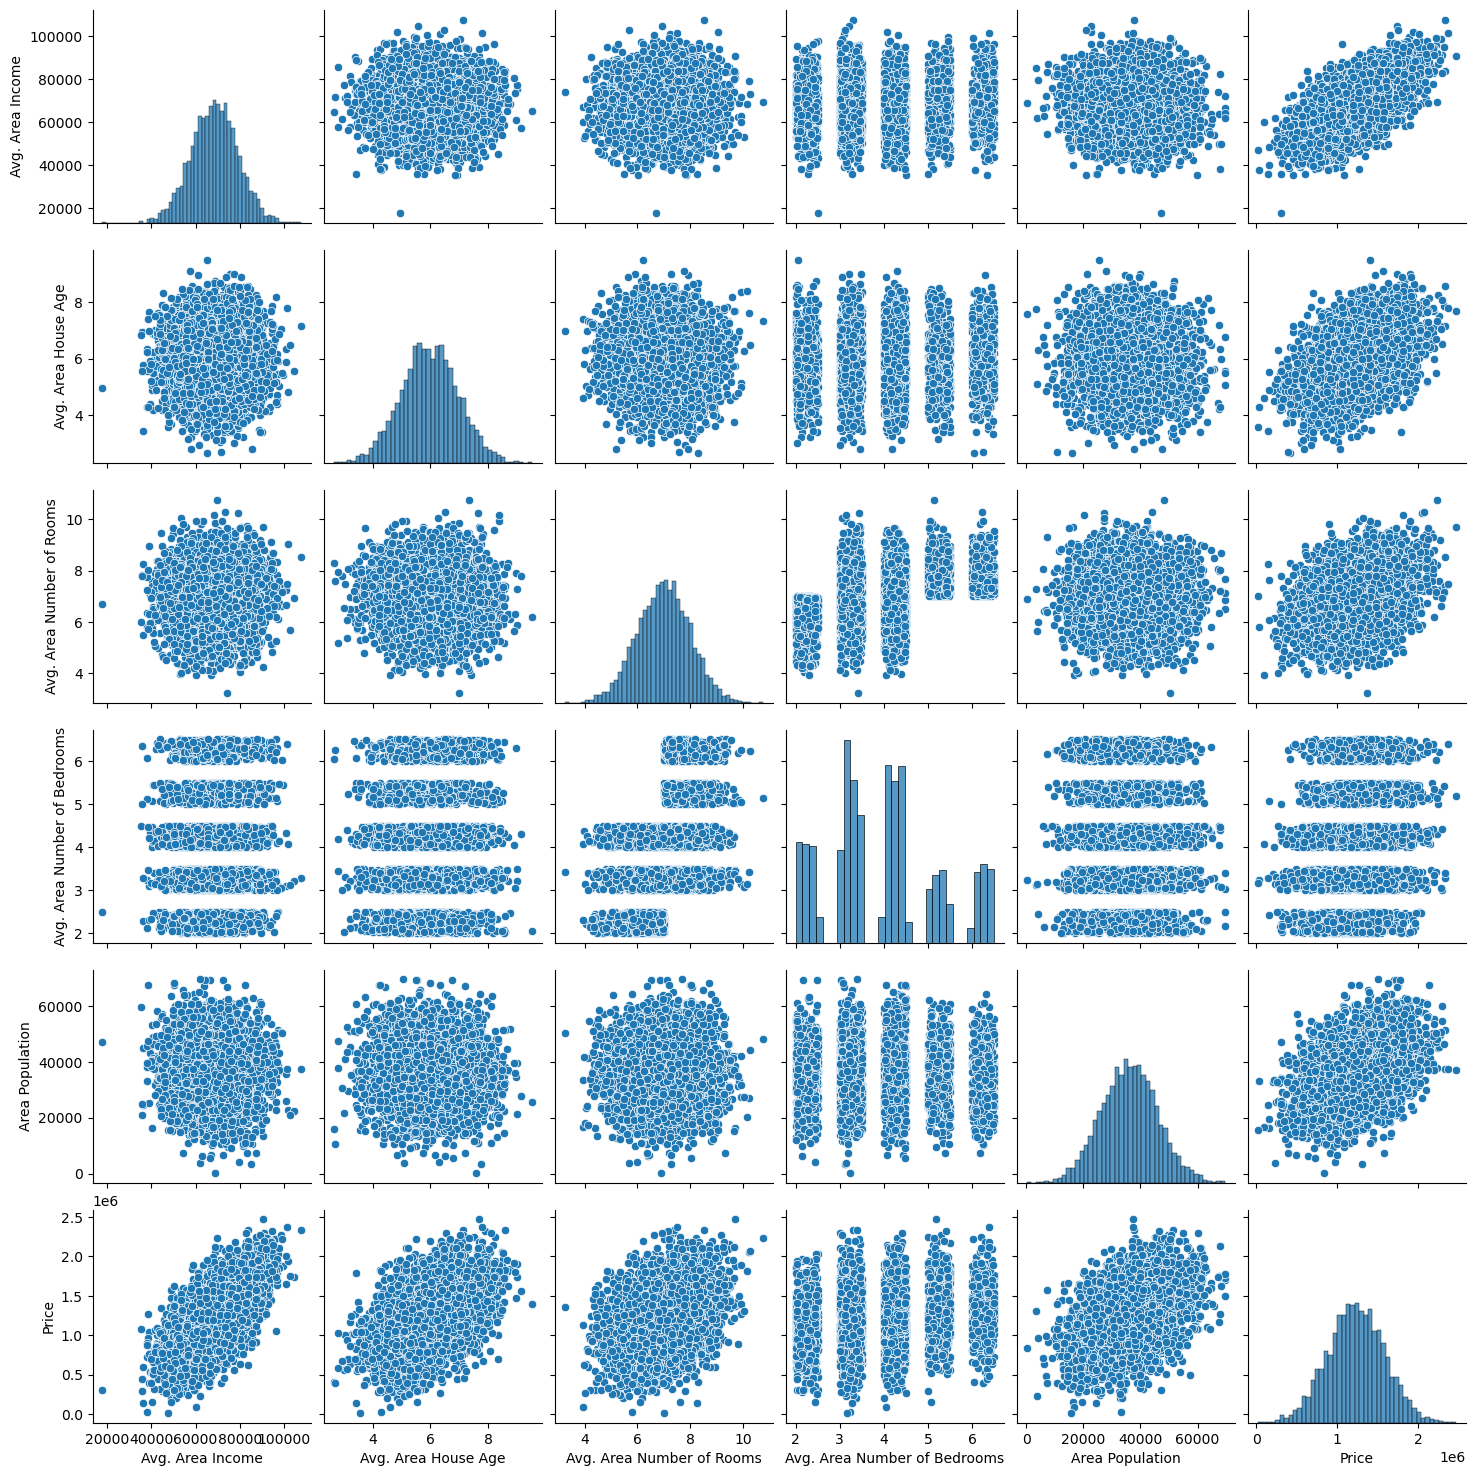

In [97]:
sns.pairplot(df)

Kita tinjau distribusi dari predicted variable kita dimana dalam hal ini adalah **PRICE**

<Axes: ylabel='Frequency'>

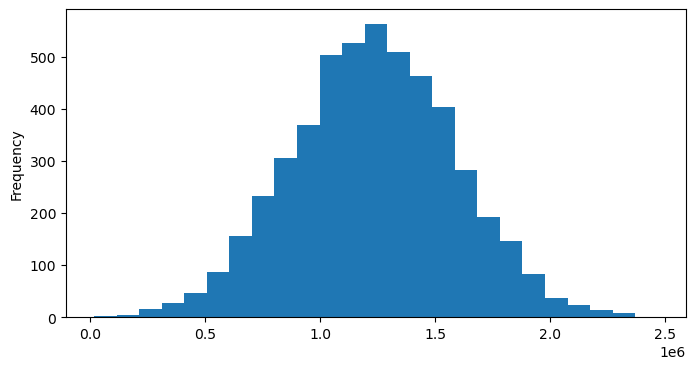

In [98]:
df['Price'].plot.hist(bins=25, figsize=(8,4))

<Axes: ylabel='Density'>

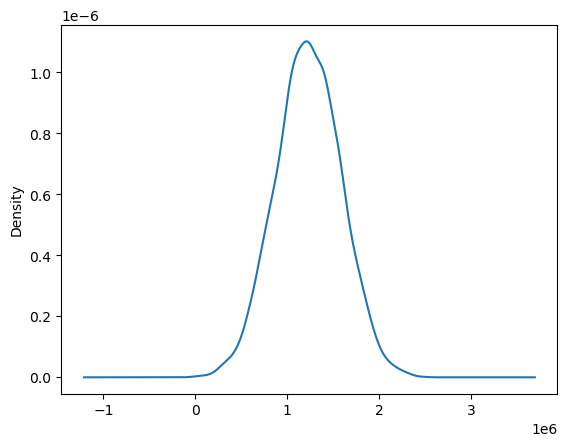

In [99]:
df['Price'].plot.density()

Kemudian kita tinjau pula korelasi antar variabel menggunakan correlation heatmap

Disini kita akan drop kolom address dan kita akan mempersiapkan dataset untuk training dengan cara memisahkan prediktor dan target variabel

In [100]:
# Drop Address dari dataset (karena tidak numerik dan tidak kategorikal)
df = df.drop(columns=['Address'])

df.head()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


melihat korelasi antar fitur

In [101]:
df.corr()

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
Avg. Area Income,1.000000,-0.002007,-0.011032,0.019788,-0.016234,0.639734
Avg. Area House Age,-0.002007,1.000000,-0.009428,0.006149,-0.018743,0.452543
Avg. Area Number of Rooms,-0.011032,-0.009428,1.000000,0.462695,0.002040,0.335664
Avg. Area Number of Bedrooms,0.019788,0.006149,0.462695,1.000000,-0.022168,0.171071
Area Population,-0.016234,-0.018743,0.002040,-0.022168,1.000000,0.408556
Price,0.639734,0.452543,0.335664,0.171071,0.408556,1.000000


<Axes: >

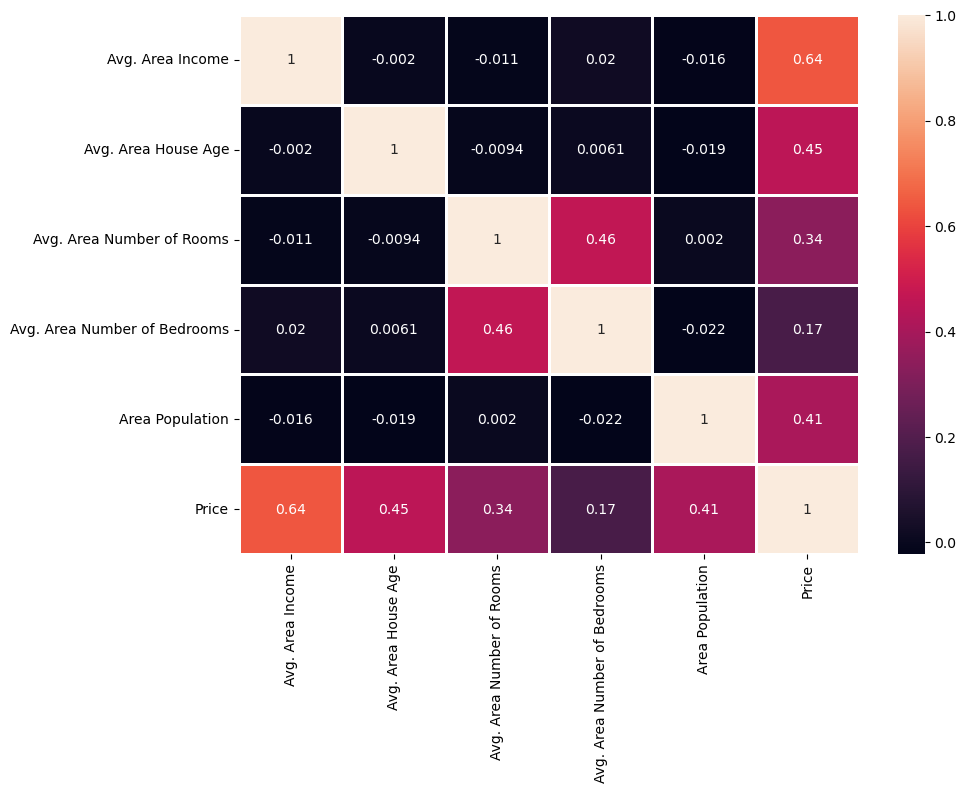

In [102]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,linewidths=2)

In [103]:
columns = list(df.columns)

# ambil kolom prediktor dan simpan di variable predictor
predictor = columns[:-1]

# ambil kolom target dan simpan di variable target
target = columns[-1]

In [104]:
df[predictor]

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [105]:
df.drop('Price', axis=1)

,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population
0,79545.458574,5.682861,7.009188,4.09,23086.800503
1,79248.642455,6.002900,6.730821,3.09,40173.072174
2,61287.067179,5.865890,8.512727,5.13,36882.159400
3,63345.240046,7.188236,5.586729,3.26,34310.242831
4,59982.197226,5.040555,7.839388,4.23,26354.109472
...,...,...,...,...,...
4995,60567.944140,7.830362,6.137356,3.46,22837.361035
4996,78491.275435,6.999135,6.576763,4.02,25616.115489
4997,63390.686886,7.250591,4.805081,2.13,33266.145490
4998,68001.331235,5.534388,7.130144,5.44,42625.620156


In [106]:
X = df[predictor]

In [107]:
y = df[target]

Kemudian kita akan melakukan split train-test

In [108]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)

print("Train size :", X_train.shape)
print("Test size :", X_test.shape)

Train size : (3500, 5)
Test size : (1500, 5)


### Training Regression Model



In [109]:
# menginisiasi object lm --> dari class LinearRegression
lm = LinearRegression()

In [110]:
# melakukan training dengan menggunakan X_train dan y_train
lm.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [111]:
print("intercept dari model kita: ", lm.intercept_)

intercept dari model kita:  -2631028.9017463764


In [112]:
print("coefficient dari linear model kita: ", lm.coef_)

coefficient dari linear model kita:  [2.15976020e+01 1.65201105e+05 1.19061464e+05 3.21258561e+03
 1.52281212e+01]


In [113]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=['Coefficients'])
cdf

,Coefficients
Avg. Area Income,21.597602
Avg. Area House Age,165201.104954
Avg. Area Number of Rooms,119061.463868
Avg. Area Number of Bedrooms,3212.585606
Area Population,15.228121


### Training Result Analysis

Coefficient, standard error, and T-statistic for each predictor

In [114]:
n=X_train.shape[0] #jumalh data training
k=X_train.shape[1] #jumlah fitur independent (5 fitur)
dfN = n-k #dalammenghitung standard error, kita menggunakan derajat kebebasan(dfn)

train_pred=lm.predict(X_train) #prediksi model di data training
train_error = np.square(train_pred - y_train) #menghitung error kuadrat
sum_error=np.sum(train_error) #jumlah error kuadratnya

se=[0,0,0,0,0] #inisialisasi awal sebelum nilai standard error(se) dihitung
for i in range(k):
    r = (sum_error/dfN) #residual mse
    r = r/np.sum(np.square(X_train[list(X_train.columns)[i]]-X_train[list(X_train.columns)[i]].mean()))
    se[i]=np.sqrt(r) #menghitung se untuk masing2 koefisien

cdf['Standard Error']=se
cdf['t-statistic']=cdf['Coefficients']/cdf['Standard Error'] #menghitung t-statistic
cdf

,Coefficients,Standard Error,t-statistic
Avg. Area Income,21.597602,0.160361,134.681505
Avg. Area House Age,165201.104954,1722.412068,95.912649
Avg. Area Number of Rooms,119061.463868,1696.546476,70.178722
Avg. Area Number of Bedrooms,3212.585606,1376.451759,2.333962
Area Population,15.228121,0.169882,89.639472


* **Avg. Area Number of Bedrooms **memiliki nilai t-statistik paling kecil, yang mungkin berarti tidak terlalu signifikan dibandingkan fitur lainnya.
* **Avg. Area House Age dan Avg. Area Number of Rooms **memiliki pengaruh paling besar terhadap variabel target.

**Kesimpulan**

1. Koefisien vs. t-statistic: Apa yang Lebih Penting?
* Koefisien (Coefficient) → Mengukur efek absolut fitur terhadap target
Avg. Area House Age (165201.10) & Avg. Area Number of Rooms (119061.46) memiliki nilai koefisien yang jauh lebih besar daripada Avg. Area Income (21.60).
* Artinya, jika fitur ini berubah 1 unit, pengaruhnya terhadap harga rumah jauh lebih besar dibandingkan Avg. Area Income.

2. t-statistic → Mengukur signifikansi fitur terhadap model
* Avg. Area Income memiliki t-statistic tertinggi karena standard error-nya kecil, bukan karena dampaknya besar.
* Standard error kecil berarti ada sedikit variabilitas dalam data, sehingga prediksi untuk fitur ini lebih stabil.

Text(0.5, 1.0, 'Area Population vs. Price')

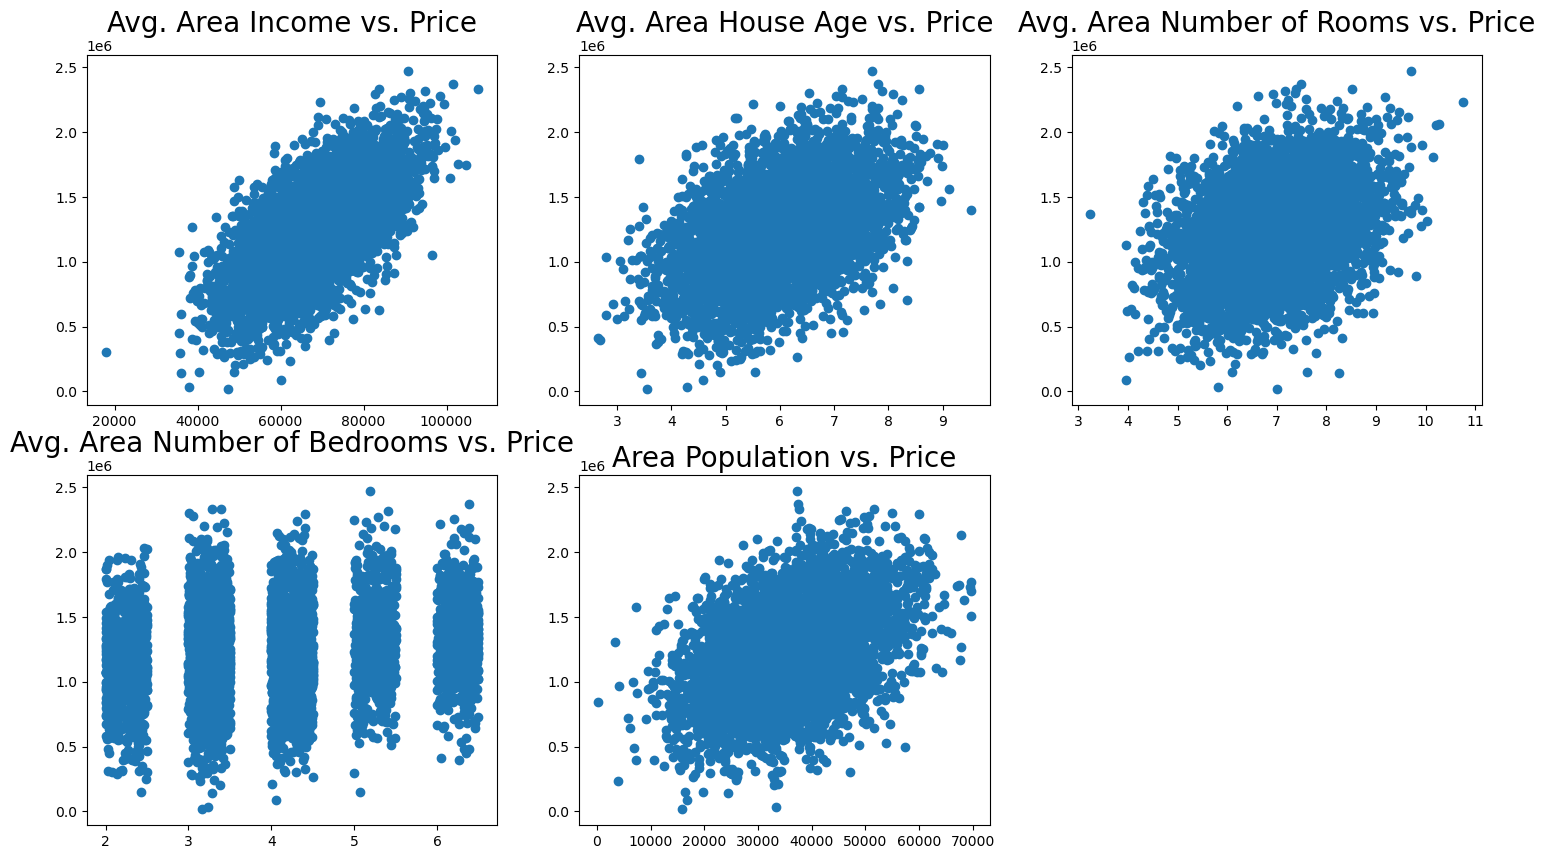

In [115]:
# Visualisasi prediktor vs target

l=list(cdf.index)
from matplotlib import gridspec
fig = plt.figure(figsize=(18, 10))
gs = gridspec.GridSpec(2,3)
#f, ax = plt.subplots(nrows=1,ncols=len(l), sharey=True)
ax0 = plt.subplot(gs[0])
ax0.scatter(df[l[0]],df['Price'])
ax0.set_title(l[0]+" vs. Price", fontdict={'fontsize':20})

ax1 = plt.subplot(gs[1])
ax1.scatter(df[l[1]],df['Price'])
ax1.set_title(l[1]+" vs. Price",fontdict={'fontsize':20})

ax2 = plt.subplot(gs[2])
ax2.scatter(df[l[2]],df['Price'])
ax2.set_title(l[2]+" vs. Price",fontdict={'fontsize':20})

ax3 = plt.subplot(gs[3])
ax3.scatter(df[l[3]],df['Price'])
ax3.set_title(l[3]+" vs. Price",fontdict={'fontsize':20})

ax4 = plt.subplot(gs[4])
ax4.scatter(df[l[4]],df['Price'])
ax4.set_title(l[4]+" vs. Price",fontdict={'fontsize':20})

### Evaluasi Model dan Uji Asumsi
Setelah melakukan training dan menghasilkan hasil evaluasi, kita perlu melakukan uji asumsi agar dapat memastikan bahwa model kita dapat diandalkan dan valid

In [116]:
predictions = lm.predict(X_test) #uji model menggunakan data test

# menghitung residual dari hasil regresi kita
residuals = (y_test - predictions)

residuals

2648      9022.720049
2456     10121.863342
4557   -196214.531062
4884     33224.548599
92     -194659.145897
            ...      
3014    -75988.312262
734      19097.223427
452     -17412.879890
2558     14302.186459
1927    -53467.422428
Name: Price, Length: 1500, dtype: float64

In [117]:
# melakukan uji normalitas dengan shapiro wilk
shapiro_test_stat, shapiro_p_value = shapiro(residuals)
print("shapiro test stat : ", shapiro_test_stat)
print("shapiro p value :", shapiro_p_value)

shapiro test stat :  0.9990341525525548
shapiro p value : 0.6245392498071436


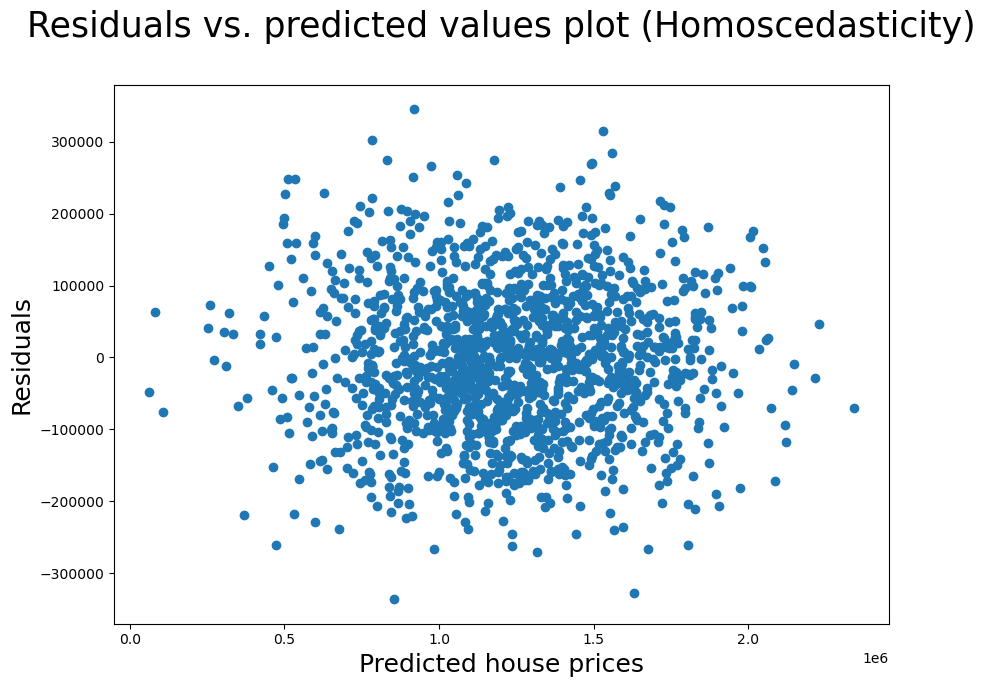

In [118]:
plt.figure(figsize=(10,7))
plt.title("Residuals vs. predicted values plot (Homoscedasticity)\n",fontsize=25)
plt.xlabel("Predicted house prices",fontsize=18)
plt.ylabel("Residuals", fontsize=18)
plt.scatter(x=predictions,y=y_test-predictions)

* Residuals yaitu selisih antara nilai aktual dan prediksi.
* Penyebaran residual terlihat cukup merata di sekitar nol, tanpa pola tertentu yang jelas.
* Tidak ada pola kipas atau pola berbentuk parabola, yang berarti homoskedastisitas cukup terpenuhi.
* tetapi ada sedikit outlier artiny "Model terlalu meremehkan atau melebihkan  harga rumah (harga asli jauh lebih tinggi dari prediksi) atau (harga asli jauh lebih rendah dari pada prediksi)."

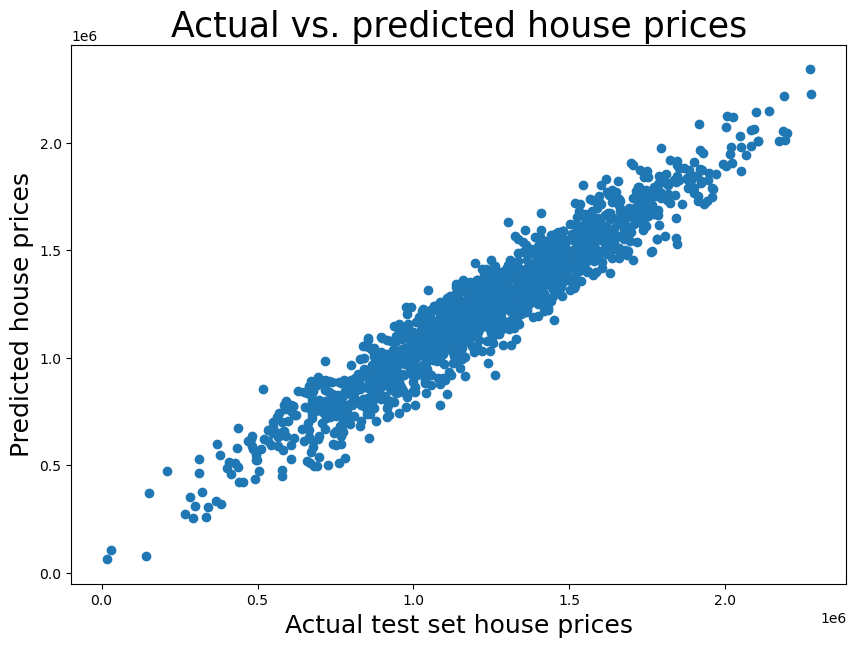

In [119]:
plt.figure(figsize=(10,7))
plt.title("Actual vs. predicted house prices",fontsize=25)
plt.xlabel("Actual test set house prices",fontsize=18)
plt.ylabel("Predicted house prices", fontsize=18)
plt.scatter(x=y_test,y=predictions)

Model cukup baik dalam memprediksi harga rumah secara umum walau ada beberapa outlier

hasil evaluasi dengan melihat MAE, RMSE, R^2

In [120]:
print("MAE:", metrics.mean_absolute_error(y_test,predictions))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test,predictions)))
print("R-squared test:", round(metrics.r2_score(y_test,predictions),3))
print("R-squared train:", round(metrics.r2_score(y_train,lm.predict(X_train)),3))

MAE: 81739.77482718245
RMSE: 102418.93543581416
R-squared test: 0.919
R-squared train: 0.917


# **KESIMPULAN**
1. Rata-rata kesalahan prediksi sekitar 8.17% dari harga rumah rata-rata.
2. Model sudah cukup baik, dengan akurasi tinggi (R² sekitar 0.92) artiny model mampu menjelaskan 92% variansi dalam data uji walau terdapat kesalahan relatif kecil (MAE dan RMSE dalam batas wajar).
3. Namun, RMSE lebih tinggi dari MAE, menunjukkan adanya beberapa prediksi dengan error yang besar (outliers).